In [1]:
from vcf2pandas import vcf2pandas
import pandas as pd
import numpy as np

info_fields = {
    # ./-/+ --> 0:. 1:-/+
    'AG_Created': 'AGcheck_AG_Created',
    'AG_Lost': 'AGcheck_AG_Lost',
    'GT_Created': 'AGcheck_GT_Created',
    'GT_Lost': 'AGcheck_GT_Lost',
    # SNV/INDEL/INSDEL --> one hot encode
    'Variant_Type': 'AGcheck_Variant_Type',

    'Branchpointer_Prob': 'Branchpointer_Prob',
    'Branchpointer_U2_Binding_Energy': 'Branchpointer_U2_Binding_Energy',
    'Branchpointer_max_Prob': 'Branchpointer_max_Prob',
    'Branchpointer_max_U2_Binding_Energy': 'Branchpointer_max_U2_Binding_Energy',
    'Branchpointer_options': 'Branchpointer_options',

    'ESE_A1_Hazeem_alt': 'ESE_A1_Hazeem_alt',
    'ESE_A1_Hazeem_diff': 'ESE_A1_Hazeem_diff',
    'ESE_A1_Hazeem_july_alt': 'ESE_A1_Hazeem_july_alt',
    'ESE_A1_Hazeem_july_diff': 'ESE_A1_Hazeem_july_diff',
    'ESE_A1_neuBG_alt': 'ESE_A1_neuBG_alt',
    'ESE_A1_neuBG_diff': 'ESE_A1_neuBG_diff',
    'ESE_A1_winBG_alt': 'ESE_A1_winBG_alt',
    'ESE_A1_winBG_diff': 'ESE_A1_winBG_diff',
    'ESE_SRSF1_alt': 'ESE_SRSF1_alt',
    'ESE_SRSF1_diff': 'ESE_SRSF1_diff',
    'ESE_SRSF1_igM_alt': 'ESE_SRSF1_igM_alt',
    'ESE_SRSF1_igM_diff': 'ESE_SRSF1_igM_diff',
    'ESE_SRSF2_alt': 'ESE_SRSF2_alt',
    'ESE_SRSF2_diff': 'ESE_SRSF2_diff',
    'ESE_SRSF5_alt': 'ESE_SRSF5_alt',
    'ESE_SRSF5_diff': 'ESE_SRSF5_diff',
    'ESE_SRSF6_alt': 'ESE_SRSF6_alt',
    'ESE_SRSF6_diff': 'ESE_SRSF6_diff',

    'MMSplice_alt_acceptor': 'MMSplice_alt_acceptor',
    'MMSplice_alt_acceptor_intron': 'MMSplice_alt_acceptor_intron',
    'MMSplice_alt_donor': 'MMSplice_alt_donor',
    'MMSplice_alt_donor_intron': 'MMSplice_alt_donor_intron',
    'MMSplice_alt_exon': 'MMSplice_alt_exon',
    'MMSplice_delta_logit_PSI': 'MMSplice_delta_logit_PSI',
    'MMSplice_pathogenicity': 'MMSplice_pathogenicity',
    'MMSplice_ref_acceptor': 'MMSplice_ref_acceptor',
    'MMSplice_ref_acceptor_intron': 'MMSplice_ref_acceptor_intron',
    'MMSplice_ref_donor': 'MMSplice_ref_donor',
    'MMSplice_ref_donor_intron': 'MMSplice_ref_donor_intron',
    'MMSplice_ref_exon': 'MMSplice_ref_exon',

    'Pangolin_Gain': 'Pangolin_Gain',
    'Pangolin_Loss': 'Pangolin_Loss',

    'SPIP_Range_Max': 'SPIP_Range_Max',
    'SPIP_Range_Min': 'SPIP_Range_Min',
    'SPIP_Score': 'SPIP_Score',
    'SPiCE_Prob': 'SPIP_SPiCE_Prob',

    'DP_AG': 'SpliceAI_DP_AG',
    'DP_AL': 'SpliceAI_DP_AL',
    'DP_DG': 'SpliceAI_DP_DG',
    'DP_DL': 'SpliceAI_DP_DL',
    'DS_AG': 'SpliceAI_DS_AG',
    'DS_AG_ALT': 'SpliceAI_DS_AG_ALT',
    'DS_AL': 'SpliceAI_DS_AL',
    'DS_AL_ALT': 'SpliceAI_DS_AL_ALT',
    'DS_DG': 'SpliceAI_DS_DG',
    'DS_DG_ALT': 'SpliceAI_DS_DG_ALT',
    'DS_DL': 'SpliceAI_DS_DL',
    'DS_DL_ALT': 'SpliceAI_DS_DL_ALT',

    'AccGainP': 'Spliceogen_AccGainP',
    'AccLossP': 'Spliceogen_AccLossP',
    'DonGainP': 'Spliceogen_DonGainP',
    'DonLossP': 'Spliceogen_DonLossP',
    'ESEmaxAlt': 'Spliceogen_ESEmaxAlt',
    'ESEmaxRef': 'Spliceogen_ESEmaxRef',
    'ESSminAlt': 'Spliceogen_ESSminAlt',
    'ESSminRef': 'Spliceogen_ESSminRef',
    'mesAccAlt': 'Spliceogen_mesAccAlt',
    'mesAccRef': 'Spliceogen_mesAccRef',
    'mesDonAlt': 'Spliceogen_mesDonAlt',
    'mesDonRef': 'Spliceogen_mesDonRef',

    # U12/.      --> 0:. 1:U12
    'Intron_Type': 'U12_Intron_Type',
    # score/dots --> 0:.
    'U12_score': 'U12_score',
    # ./-/+      --> 0:. 1:-/+
    # 'U12_strand': 'U12_strand',

    # [('acceptor_canonical',) ('donor_region',) '.' ('donor_exonic',)
    #  ('acceptor_exonic',) ('donor_canonical',) ('branchpoint_region',)
    #  ('acceptor_region',)]
    'gene_regions': 'GENEINFO_gene_regions',

    ### Gencode file
    # intronic/exonic
    'Gene_Location': 'GENEINFO_is_intronic',
    # Exclude
    # 'gene': 'gene',

    # Exclude
    # [('protein_coding',) ('protein_coding', 'lncRNA')
    #  ('lncRNA', 'protein_coding')
    #  ('lncRNA', 'transcribed_unprocessed_pseudogene') ('lncRNA',) etc.
    # 'gene_type': 'gene_type',

    # [('-',) ('+',) ('+', '-') ('-', '+')]
    'strand': 'GENEINFO_strand',
    }

df = vcf2pandas("./FEB_25-bignewgpu__test.highquality.annotated.filtered.ensemblescored.otherannos.vcf",
    remove_empty_columns=True,
    info_fields=info_fields)

In [2]:
pd.set_option('display.max_columns', None)
df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO:AGcheck_AG_Created,INFO:AGcheck_AG_Lost,INFO:AGcheck_GT_Created,INFO:AGcheck_GT_Lost,INFO:AGcheck_Variant_Type,INFO:Branchpointer_Prob,INFO:Branchpointer_U2_Binding_Energy,INFO:Branchpointer_max_Prob,INFO:Branchpointer_max_U2_Binding_Energy,INFO:Branchpointer_options,INFO:ESE_A1_Hazeem_alt,INFO:ESE_A1_Hazeem_diff,INFO:ESE_A1_Hazeem_july_alt,INFO:ESE_A1_Hazeem_july_diff,INFO:ESE_A1_neuBG_alt,INFO:ESE_A1_neuBG_diff,INFO:ESE_A1_winBG_alt,INFO:ESE_A1_winBG_diff,INFO:ESE_SRSF1_alt,INFO:ESE_SRSF1_diff,INFO:ESE_SRSF1_igM_alt,INFO:ESE_SRSF1_igM_diff,INFO:ESE_SRSF2_alt,INFO:ESE_SRSF2_diff,INFO:ESE_SRSF5_alt,INFO:ESE_SRSF5_diff,INFO:ESE_SRSF6_alt,INFO:ESE_SRSF6_diff,INFO:MMSplice_alt_acceptor,INFO:MMSplice_alt_acceptor_intron,INFO:MMSplice_alt_donor,INFO:MMSplice_alt_donor_intron,INFO:MMSplice_alt_exon,INFO:MMSplice_delta_logit_PSI,INFO:MMSplice_pathogenicity,INFO:MMSplice_ref_acceptor,INFO:MMSplice_ref_acceptor_intron,INFO:MMSplice_ref_donor,INFO:MMSplice_ref_donor_intron,INFO:MMSplice_ref_exon,INFO:Pangolin_Gain,INFO:Pangolin_Loss,INFO:SPIP_Range_Max,INFO:SPIP_Range_Min,INFO:SPIP_Score,INFO:SPIP_SPiCE_Prob,INFO:SpliceAI_DP_AG,INFO:SpliceAI_DP_AL,INFO:SpliceAI_DP_DG,INFO:SpliceAI_DP_DL,INFO:SpliceAI_DS_AG,INFO:SpliceAI_DS_AG_ALT,INFO:SpliceAI_DS_AL,INFO:SpliceAI_DS_AL_ALT,INFO:SpliceAI_DS_DG,INFO:SpliceAI_DS_DG_ALT,INFO:SpliceAI_DS_DL,INFO:SpliceAI_DS_DL_ALT,INFO:Spliceogen_AccGainP,INFO:Spliceogen_AccLossP,INFO:Spliceogen_DonGainP,INFO:Spliceogen_DonLossP,INFO:Spliceogen_ESEmaxAlt,INFO:Spliceogen_ESEmaxRef,INFO:Spliceogen_ESSminAlt,INFO:Spliceogen_ESSminRef,INFO:Spliceogen_mesAccAlt,INFO:Spliceogen_mesAccRef,INFO:Spliceogen_mesDonAlt,INFO:Spliceogen_mesDonRef,INFO:U12_Intron_Type,INFO:U12_score,INFO:GENEINFO_gene_regions,INFO:GENEINFO_is_intronic,INFO:GENEINFO_strand
0,chr1,945655,SVDBSplice,T,"(A,)",None,PASS,.,"(-,)",.,.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,-2.099,1.935,-0.431,0,0,2.801,0.027,0,0,"(-0.2199999988079071,)","(-4.505000114440918,)","(2.7860000133514404,)","(-0.09700000286102295,)","(-1.555999994277954,)","(-2.8420000076293945,)","(1.0,)","(3.7100000381469727,)","(-4.505000114440918,)","(2.7860000133514404,)","(-0.09700000286102295,)","(-1.555999994277954,)","(0.8199999928474426,)","(-0.8600000143051147,)","(99.95999908447266,)","(91.47000122070312,)","(98.41000366210938,)","(0.9999600052833557,)","(-9.0,)","(-2.0,)","(-332.0,)","(373.0,)","(0.9599999785423279,)","(0.9599999785423279,)","(0.9200000166893005,)","(0.07999999821186066,)","(0.019999999552965164,)","(0.07999999821186066,)","(0.019999999552965164,)","(0.41999998688697815,)",0.98,0.98,.,.,0.484,.,-0.21,-0.365,3.1,8.85,.,.,.,.,"(acceptor_canonical,)","(intronic,)","(-,)"
1,chr1,951995,SVDBSplice,C,"(T,)",None,PASS,.,"(-,)",.,"(-,)","(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,0,0,0,3.175,3.175,0,0,0,0,"(3.6059999465942383,)","(-2.9630000591278076,)","(-2.0169999599456787,)","(0.32100000977516174,)","(-3.947999954223633,)","(-4.590000152587891,)","(1.0,)","(3.6059999465942383,)","(-2.9630000591278076,)","(4.1020002365112305,)","(0.32100000977516174,)","(-3.947999954223633,)","(0.1599999964237213,)","(-0.7099999785423279,)","(99.95999908447266,)","(91.47000122070312,)","(98.41000366210938,)","(0.9996600151062012,)","(205.0,)","(144.0,)","(116.0,)","(5.0,)","(0.009999999776482582,)","(0.009999999776482582,)","(0.5799999833106995,)","(0.41999998688697815,)","(0.10999999940395355,)","(0.10999999940395355,)","(0.7599999904632568,)","(0.23999999463558197,)",.,.,0.00,0.99,0.199,0.132,-0.157,-0.374,1.76,0.71,1.48,9.1,.,.,"(donor_region,)","(intronic,)","(-,)"
2,chr1,963993,SVDBSplice,C,"(T,)",None,PASS,.,.,"(+,)",.,"(SNV,)",.,.,.,.,.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.533,0.357,2.821,2.821,"(1.5019999742507935,)","(-4.7779998779296875,)","(1.2059999704360962,)","(-0.25099998712539673,)","(-2.183000087738037,)","(-0.19900000095367432,)","(0.5979999899864197,)","(1.5019999742507935,)","(-4.7779998779296875,)","(1.2059999704360962,)","(-0.250999987

In [3]:
for col in df.columns:
    if col == "REF" or col == "ALT":
        continue
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Column: {col}")
        print("Unique values:", df[col].unique())
        print()

Column: CHROM
Unique values: ['chr1' 'chr2' 'chr3' 'chr4' 'chr5' 'chr6' 'chr7' 'chr8' 'chr9' 'chr10'
 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17' 'chr18' 'chr19'
 'chr20' 'chr21' 'chr22' 'chrX' 'chrY']

Column: ID
Unique values: ['SVDBSplice' 'SVDBNormal' 'SVDBConflicting']

Column: QUAL
Unique values: [None]

Column: FILTER
Unique values: ['PASS']

Column: INFO:AGcheck_AG_Created
Unique values: ['.' ('-',) ('+',)]

Column: INFO:AGcheck_AG_Lost
Unique values: [('-',) '.' ('+',)]

Column: INFO:AGcheck_GT_Created
Unique values: ['.' ('+',) ('-',)]

Column: INFO:AGcheck_GT_Lost
Unique values: ['.' ('-',) ('+',)]

Column: INFO:AGcheck_Variant_Type
Unique values: [('SNV',) ('INDEL',) ('INSDEL',)]

Column: INFO:Branchpointer_Prob
Unique values: ['.' 1.399999976158142 2.9000000953674316 3.299999952316284
 1.600000023841858 2.700000047683716 1.0 0.30000001192092896
 0.699999988079071 0.10000000149011612 7.0 5.099999904632568
 1.100000023841858 5.800000190734863 0.800000011920929 4.

In [4]:
ese        = [col for col in df.columns if col.startswith('INFO:ESE_')]
mmsplice   = [col for col in df.columns if col.startswith('INFO:MMSplice_')]
pangolin   = [col for col in df.columns if col.startswith('INFO:Pangolin_')]
spip       = [col for col in df.columns if col.startswith('INFO:SPIP_')]
spliceai   = [col for col in df.columns if col.startswith('INFO:SpliceAI_')]
spliceogen = [col for col in df.columns if col.startswith('INFO:Spliceogen_')]

ensemble_scores = [ese, mmsplice, pangolin, spliceai, spliceogen, spip]

for l in ensemble_scores:
    print(len(l), l)


18 ['INFO:ESE_A1_Hazeem_alt', 'INFO:ESE_A1_Hazeem_diff', 'INFO:ESE_A1_Hazeem_july_alt', 'INFO:ESE_A1_Hazeem_july_diff', 'INFO:ESE_A1_neuBG_alt', 'INFO:ESE_A1_neuBG_diff', 'INFO:ESE_A1_winBG_alt', 'INFO:ESE_A1_winBG_diff', 'INFO:ESE_SRSF1_alt', 'INFO:ESE_SRSF1_diff', 'INFO:ESE_SRSF1_igM_alt', 'INFO:ESE_SRSF1_igM_diff', 'INFO:ESE_SRSF2_alt', 'INFO:ESE_SRSF2_diff', 'INFO:ESE_SRSF5_alt', 'INFO:ESE_SRSF5_diff', 'INFO:ESE_SRSF6_alt', 'INFO:ESE_SRSF6_diff']
12 ['INFO:MMSplice_alt_acceptor', 'INFO:MMSplice_alt_acceptor_intron', 'INFO:MMSplice_alt_donor', 'INFO:MMSplice_alt_donor_intron', 'INFO:MMSplice_alt_exon', 'INFO:MMSplice_delta_logit_PSI', 'INFO:MMSplice_pathogenicity', 'INFO:MMSplice_ref_acceptor', 'INFO:MMSplice_ref_acceptor_intron', 'INFO:MMSplice_ref_donor', 'INFO:MMSplice_ref_donor_intron', 'INFO:MMSplice_ref_exon']
2 ['INFO:Pangolin_Gain', 'INFO:Pangolin_Loss']
12 ['INFO:SpliceAI_DP_AG', 'INFO:SpliceAI_DP_AL', 'INFO:SpliceAI_DP_DG', 'INFO:SpliceAI_DP_DL', 'INFO:SpliceAI_DS_AG', 'IN

In [5]:
def assert_and_convert_single_float_tuples_allow_dot(df: pd.DataFrame, *,
                                                    #  ok_nonnumerical: list[str],
                                                     dots_zeros: list[str],
                                                     nans_zeros: list[str]) -> pd.DataFrame:
    """
    For each column in df:
      - If the column contains any tuples, assert that every tuple is either:
          * length-1 and contains a float, or
          * is None, or
          * equals the string "."
      - Convert such valid single-float tuples to the float value.
      - Leave the "." string as-is instead of trying to convert it to float.
    Returns a copy of df with the converted columns (dtype may remain 'object' 
    if "." strings are present).
    """
    df = df.copy()
    
    for col in df.columns:
        # Check if this column contains *any* tuples
        has_tuple = df[col].apply(lambda x: isinstance(x, tuple)).any()
        
        if has_tuple:
            # Define a helper to check if each value is valid
            def is_valid_tuple(x):
                # Valid if it's None, or the special ".", or a single-float tuple
                if x is None or x == "." or not isinstance(x, tuple):
                    return True
                if (x[0] is None):
                    print(col, x[0])
                return (len(x) == 1 and (isinstance(x[0], float) or x[0] is None))
            
            # If any row fails the validity check, raise an error
            valid_series = df[col].apply(is_valid_tuple)
            if not valid_series.all():
                # Extract offending values
                offending_values = df[col][~valid_series].unique()
                raise ValueError(
                    f"Column '{col}' contains invalid tuple values: {offending_values}"
                )
            
        # Convert single-float tuples to that float
        def convert_tuple_to_float(x):
            if isinstance(x, tuple):
                return sanitise(x[0])  # we've already asserted it's length-1 float
            return sanitise(x)
        
        def sanitise(x):
            if not (str(x) in ["", ".", "NaN", "nan", "None"]):
                return x
            if any(col.startswith(x) for x in dots_zeros) and (str(x) == "." or str(x) == ""):
                return 0
            if any(col.startswith(x) for x in nans_zeros) and str(x) in ["NaN", "nan", "None"]:
                return 0
            return x
        
        df[col] = df[col].apply(convert_tuple_to_float)
            
            # If you wanted to convert *everything* that *can* be a float (except "."),
            # you could do something like this:
            #
            #     def try_float(x):
            #         if x == "." or x is None:
            #             return x  # leave "." or None as-is
            #         try:
            #             return float(x)
            #         except (ValueError, TypeError):
            #             return x
            #
            #     df[col] = df[col].apply(try_float)
            #
            # However, if you only need to convert the tuples (and trust the rest 
            # are already correct), the above tuple conversion alone might suffice.
    # if dots_zeros:
    #     df = df.astype(str).replace(to_replace=["."], value=("0"))
    
    # if nans_zeros:
    #     df = df.astype(str).replace(to_replace=["NaN", "nan", "None"], value=("0"))
    
    # df = df.astype(str).replace(to_replace=["True"], value=("1"))
    # df = df.astype(str).replace(to_replace=["False"], value=("0"))
    
    return df

## Cleaning

df_rem = df[df['ID'] != 'SVDBConflicting']
df_rem = pd.get_dummies(df_rem, columns=['ID'])
df_rem

for col in [col for col in df.columns if col.startswith('INFO:AGcheck_')]:
    if not col.endswith('Created') and not col.endswith('Lost'):
        continue
    # Convert AGcheck to 0 is dot, and 1 is minus OR plus
    df_rem[col] = (df_rem[col] != '.')

df_rem = pd.get_dummies(df_rem, columns=['INFO:AGcheck_Variant_Type'])

# Convert U12_Intron_Type to U12_Intron_Type ("U12" -> 1, otherwise 0)
df_rem['INFO:U12_Intron_Type'] = (df_rem['INFO:U12_Intron_Type'] == 'U12')
# Convert U12_strand to 0 is dot, and 1 is minus OR plus
# df_rem['INFO:U12_strand'] = (df_rem['INFO:U12_strand'] != '.').astype(int)


df_rem = pd.get_dummies(df_rem, columns=['INFO:GENEINFO_gene_regions'])

df_rem['INFO:GENEINFO_is_intronic'] = (df_rem['INFO:GENEINFO_is_intronic'] == ('intronic',))

df_rem['strand_minus'] = df_rem['INFO:GENEINFO_strand'].apply(lambda x: '-' in x)
df_rem['strand_plus'] = df_rem['INFO:GENEINFO_strand'].apply(lambda x: '+' in x)
df_rem = df_rem.drop(columns=['INFO:GENEINFO_strand'])

agcheck    = [col for col in df_rem.columns if col.startswith('INFO:AGcheck_')]
bpter      = [col for col in df_rem.columns if col.startswith('INFO:Branchpointer_')]
u12        = [col for col in df_rem.columns if col.startswith('INFO:U12_')]
geneinfo   = [col for col in df_rem.columns if col.startswith('INFO:GENEINFO_')]
info       = [agcheck, bpter, u12, geneinfo]


In [6]:
for col in df_rem.columns:
    if col == "REF" or col == "ALT":
        continue
    print(f"Column: {col}")
    print("Unique values:", df_rem[col].unique())
    print()

Column: CHROM
Unique values: ['chr1' 'chr2' 'chr3' 'chr4' 'chr5' 'chr6' 'chr7' 'chr8' 'chr9' 'chr10'
 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17' 'chr18' 'chr19'
 'chr20' 'chr21' 'chr22' 'chrX' 'chrY']

Column: POS
Unique values: [  945655   951995   963993 ... 19743144 19743165 19743205]

Column: QUAL
Unique values: [None]

Column: FILTER
Unique values: ['PASS']

Column: INFO:AGcheck_AG_Created
Unique values: [False  True]

Column: INFO:AGcheck_AG_Lost
Unique values: [ True False]

Column: INFO:AGcheck_GT_Created
Unique values: [False  True]

Column: INFO:AGcheck_GT_Lost
Unique values: [False  True]

Column: INFO:Branchpointer_Prob
Unique values: ['.' 1.399999976158142 2.9000000953674316 3.299999952316284
 1.600000023841858 2.700000047683716 1.0 0.30000001192092896
 0.699999988079071 0.10000000149011612 7.0 5.099999904632568
 1.100000023841858 5.800000190734863 0.800000011920929 4.699999809265137
 1.2999999523162842 0.5 4.0 8.100000381469727 0.4000000059604645
 3.400000095

In [7]:
scores = spliceai

from itertools import chain
scores = scores.copy()
scores.extend(list(chain.from_iterable(info)))
columns = scores + ['ID_SVDBSplice']
print(f"{len(columns)=} {columns=}")
features = assert_and_convert_single_float_tuples_allow_dot(df_rem[columns],
                                                            # dots_zeros=['INFO:Spliceogen_',
                                                            #             'INFO:Branchpointer_'
                                                            #             'INFO:U12_score'],
                                                            dots_zeros=['INFO'],
                                                            nans_zeros=[])
print("before:", len(features))

bad_features = features[features.isin(["."]).any(axis=1)]
features = features[~features.isin(["."]).any(axis=1)]
print("after:", len(features))

print("Removed bad features:")
print(bad_features.to_string())

features = features.astype(float).round(3)
features

len(columns)=36 columns=['INFO:SpliceAI_DP_AG', 'INFO:SpliceAI_DP_AL', 'INFO:SpliceAI_DP_DG', 'INFO:SpliceAI_DP_DL', 'INFO:SpliceAI_DS_AG', 'INFO:SpliceAI_DS_AG_ALT', 'INFO:SpliceAI_DS_AL', 'INFO:SpliceAI_DS_AL_ALT', 'INFO:SpliceAI_DS_DG', 'INFO:SpliceAI_DS_DG_ALT', 'INFO:SpliceAI_DS_DL', 'INFO:SpliceAI_DS_DL_ALT', 'INFO:AGcheck_AG_Created', 'INFO:AGcheck_AG_Lost', 'INFO:AGcheck_GT_Created', 'INFO:AGcheck_GT_Lost', "INFO:AGcheck_Variant_Type_('INDEL',)", "INFO:AGcheck_Variant_Type_('INSDEL',)", "INFO:AGcheck_Variant_Type_('SNV',)", 'INFO:Branchpointer_Prob', 'INFO:Branchpointer_U2_Binding_Energy', 'INFO:Branchpointer_max_Prob', 'INFO:Branchpointer_max_U2_Binding_Energy', 'INFO:Branchpointer_options', 'INFO:U12_Intron_Type', 'INFO:U12_score', 'INFO:GENEINFO_is_intronic', 'INFO:GENEINFO_gene_regions_.', "INFO:GENEINFO_gene_regions_('acceptor_canonical',)", "INFO:GENEINFO_gene_regions_('acceptor_exonic',)", "INFO:GENEINFO_gene_regions_('acceptor_region',)", "INFO:GENEINFO_gene_regions_('b

,INFO:SpliceAI_DP_AG,INFO:SpliceAI_DP_AL,INFO:SpliceAI_DP_DG,INFO:SpliceAI_DP_DL,INFO:SpliceAI_DS_AG,INFO:SpliceAI_DS_AG_ALT,INFO:SpliceAI_DS_AL,INFO:SpliceAI_DS_AL_ALT,INFO:SpliceAI_DS_DG,INFO:SpliceAI_DS_DG_ALT,INFO:SpliceAI_DS_DL,INFO:SpliceAI_DS_DL_ALT,INFO:AGcheck_AG_Created,INFO:AGcheck_AG_Lost,INFO:AGcheck_GT_Created,INFO:AGcheck_GT_Lost,"INFO:AGcheck_Variant_Type_('INDEL',)","INFO:AGcheck_Variant_Type_('INSDEL',)","INFO:AGcheck_Variant_Type_('SNV',)",INFO:Branchpointer_Prob,INFO:Branchpointer_U2_Binding_Energy,INFO:Branchpointer_max_Prob,INFO:Branchpointer_max_U2_Binding_Energy,INFO:Branchpointer_options,INFO:U12_Intron_Type,INFO:U12_score,INFO:GENEINFO_is_intronic,INFO:GENEINFO_gene_regions_.,"INFO:GENEINFO_gene_regions_('acceptor_canonical',)","INFO:GENEINFO_gene_regions_('acceptor_exonic',)","INFO:GENEINFO_gene_regions_('acceptor_region',)","INFO:GENEINFO_gene_regions_('branchpoint_region',)","INFO:GENEINFO_gene_regions_('donor_canonical',)","INFO:GENEINFO_gene_regions_('donor_exonic',)","INFO:GENEINFO_gene_regions_('donor_region',)",ID_SVDBSplice
0,-9.0,-2.0,-332.0,373.0,0.96,0.96,0.92,0.08,0.02,0.08,0.02,0.42,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,205.0,144.0,116.0,5.0,0.01,0.01,0.58,0.42,0.11,0.11,0.76,0.24,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,84.0,973.0,-2.0,15.0,0.12,0.42,0.00,0.30,0.96,0.99,0.67,0.27,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-494.0,-205.0,-84.0,-4.0,0.00,0.01,0.33,0.31,0.25,0.26,0.35,0.65,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-3.0,-155.0,-14.0,-3.0,0.00,0.00,0.40,0.27,0.08,0.10,0.32,0.66,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25109,-318.0,-76.0,-97.0,19.0,0.00,0.02,0.01,0.05,0.00,0.01,0.00,0.99,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25110,-35.0,-2.0,-555.0,-143.0,0.51,0.69,0.98,0.00,0.05,0.20,0.09,0.91,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
25111,86.0,122.0,18.0,116.0,0.00,0.04,0.01,0.13,0.00,0.99,0.00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25112,228.0,65.0,95.0,1.0,0.03,0.64,0.00,0.04,0.00,0.01,0.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
target = features['ID_SVDBSplice']
features = features.drop(columns=['ID_SVDBSplice'])
target

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
25109    0.0
25110    1.0
25111    0.0
25112    0.0
25113    0.0
Name: ID_SVDBSplice, Length: 25031, dtype: float64

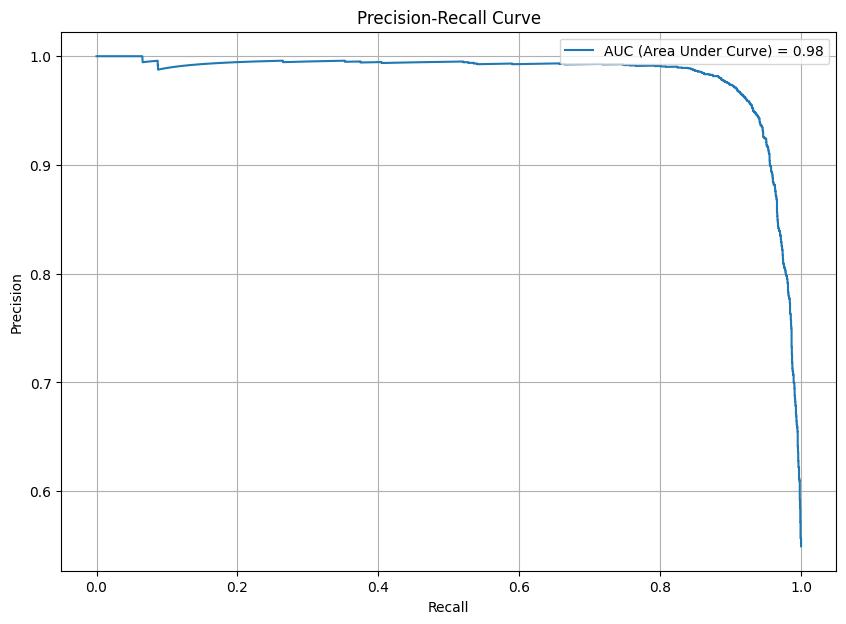

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import average_precision_score, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, f1_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)
regressor = RandomForestClassifier(n_estimators=30,
                                   random_state=42,
                                   max_depth=5,
                                   min_samples_split=5,
                                   min_samples_leaf=5,
                                   criterion='entropy',
                                   class_weight='balanced_subsample', n_jobs=-1)
regressor = HistGradientBoostingClassifier(**{'min_samples_leaf': 50, 'max_leaf_nodes': 31, 'max_iter': 200, 'max_features': 0.8, 'max_bins': 80, 'learning_rate': 0.1, 'l2_regularization': 0.1, 'class_weight': 'balanced'})
# regressor = MLPClassifier((12, 6, 6, 3), "tanh")
# regressor = LogisticRegression(class_weight='balanced')

def do_SVC(X_train_scaled):
    regressor = SVC(probability=True, class_weight='balanced')
    param_dist = {
        'C': np.logspace(-2, 2, 10),  # e.g., 0.01 to 100
        'kernel': ['rbf', 'sigmoid'],
        'gamma': ['scale', 'auto'] + list(np.logspace(-3, 0, 5)),
    }

    random_search = RandomizedSearchCV(
        estimator=regressor,
        param_distributions=param_dist,
        n_iter=20,   # number of random combinations to try
        scoring='f1',
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    random_search.fit(X_train_scaled, y_train)

    # 8. View best parameters and best score
    print("Best parameters:", random_search.best_params_)
    print("Best cross-validation score:", random_search.best_score_)

    best_svc = random_search.best_estimator_
    return best_svc

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# regressor = do_SVC(X_train)
# regressor = SVC(probability=True, class_weight='balanced',
#                 **{'kernel': 'rbf', 'gamma': np.float64(1.0), 'degree': 2, 'C': np.float64(35.93813663804626)})

regressor.fit(X_train, y_train)

# Predict probabilities
y_scores = regressor.predict_proba(X_test)[:, 1]

# Compute Precision, Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Compute Average Precision (AP)
roc_auc_score = roc_auc_score(y_test, y_scores)

# Plot PR curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, label=f'AUC (Area Under Curve) = {roc_auc_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
# plt.show()
plt.savefig("MAR5.png")

In [10]:
print('Training:')
# Compute F1 score (at a specific threshold, e.g., 0.5 for binary classification)
y_pred_train = regressor.predict(X_train)
f1 = f1_score(y_train, y_pred_train)
print(f'F1 Score: {f1:.3f}')
## Accuracy
print(f"Accuracy score (training): {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Balanced accuracy score (training): {balanced_accuracy_score(y_train, y_pred_train):.3f}")

print('Validation:')
y_pred_test = regressor.predict(X_test)
f1 = f1_score(y_test, y_pred_test)
print(f'F1 Score: {f1:.3f}')
## Accuracy
print(f"Accuracy score (test): {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Balanced accuracy score (test): {balanced_accuracy_score(y_test, y_pred_test):.3f}")


Training:
F1 Score: 0.952
Accuracy score (training): 0.949
Balanced accuracy score (training): 0.950
Validation:
F1 Score: 0.941
Accuracy score (test): 0.937
Balanced accuracy score (test): 0.938


In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import ShuffleSplit
X_train, X_test, y_train, y_test = train_test_split(
    features, target, 
    test_size=0.2, 
    random_state=42
)

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'class_weight': ['balanced'],
    'max_bins': [40, 60, 80, 100],
    'max_iter': [200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_features': [0.3, 0.4, 0.6, 0.8, 1.0],
    'max_leaf_nodes': [31, 50, 100],
    'min_samples_leaf': [20, 50, 100],
    'l2_regularization': [0.0, 0.01, 0.1],
}

# Initialize the HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_dist,
    n_iter=400,           # number of random parameter settings to try
    scoring='f1',  # evaluation metric
    cv=ShuffleSplit(n_splits=8, test_size=0.125, random_state=0),                # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,           # use all available cores
    verbose=1
)

# Perform the randomized search on training data
random_search.fit(X_train, y_train)

# Output the best parameters and best cross-validation score
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# Evaluate the best estimator on the test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred, digits=4))